# Latent Semantic Analysis using SVD

This notebook presents a topic modeling workflow using Latent Semantic Indexing (LSI) based on Singular Value Decomposition (SVD). The corpus consists of news articles from three domains: politics, accidents, and weather.

## 1. Environment setup

Installing required libraries and loading the SpaCy Polish language model.

In [ ]:
# Install dependencies
!pip install requests spacy matplotlib pandas scikit-learn wordcloud stopwordsiso plotly
!python -m spacy download pl_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 34.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Imports
import requests
import spacy
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from wordcloud import WordCloud
from matplotlib import font_manager
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from stopwordsiso import stopwords

In [ ]:
nlp = spacy.load("pl_core_news_sm")

## 2. Building the corpus

Collecting and combining articles from multiple domains into a single corpus.

In [ ]:

political_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/2b8ad0bb4d5f3fa949dff2df70171c38/raw/038e01c8de31246c81cb1afabd6d5093a0e6fdf3/artykul_polityka1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/3f2db4b292fa160fb2225c98f15260d9/raw/4590684745643876c94f83f7927bcc64741d15cd/artykul_polityka2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/7b0111fbcfd43826bfb32be8aad7a249/raw/5d13960ad0daced48e0baddd4a4afe80065cb117/artykul_polityka3.txt"
]
accident_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/901f33c6603b324a540d20db71cab26c/raw/8f498c44f7f0cc54b90f2e21522030d3549adb47/artykul_wypadek1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/50821984fcad85dc53aef8bf7ee66e59/raw/0965c604d456f3edfc5faaea6552690d7a8c83d6/artykul_wypadek2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/2343fa18cb14abfc9eac93bff9b40ea4/raw/3fa47c4beb262b391e2f003bc29a2bdb7e2ab84f/artykul_wypadek3.txt"
]
weather_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/4ae16d2c16c4d4dd1955947811e564ba/raw/69d2106871e52af1075030ae773440f97b99e25c/artykul_pogoda1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/515610869ba5b8a798bfef2ca3332f51/raw/defebead54197bd809ffd767389f08a7fb2f2703/artykul_pogoda2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/19aecc571cc2ba75bf6b65a9e61ca470/raw/b6de01fea7b15c0cfcae660f3e94f3a8c2316419/artykul_pogoda3.txt"
]

political_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/2b8ad0bb4d5f3fa949dff2df70171c38/raw/038e01c8de31246c81cb1afabd6d5093a0e6fdf3/artykul_polityka1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/3f2db4b292fa160fb2225c98f15260d9/raw/4590684745643876c94f83f7927bcc64741d15cd/artykul_polityka2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/7b0111fbcfd43826bfb32be8aad7a249/raw/5d13960ad0daced48e0baddd4a4afe80065cb117/artykul_polityka3.txt"
]

accident_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/901f33c6603b324a540d20db71cab26c/raw/8f498c44f7f0cc54b90f2e21522030d3549adb47/artykul_wypadek1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/50821984fcad85dc53aef8bf7ee66e59/raw/0965c604d456f3edfc5faaea6552690d7a8c83d6/artykul_wypadek2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/2343fa18cb14abfc9eac93bff9b40ea4/raw/3fa47c4beb262b391e2f003bc29a2bdb7e2ab84f/artykul_wypadek3.txt"
]

weather_articles = [
    "https://gist.githubusercontent.com/alaszmigiel/4ae16d2c16c4d4dd1955947811e564ba/raw/69d2106871e52af1075030ae773440f97b99e25c/artykul_pogoda1.txt",
    "https://gist.githubusercontent.com/alaszmigiel/515610869ba5b8a798bfef2ca3332f51/raw/defebead54197bd809ffd767389f08a7fb2f2703/artykul_pogoda2.txt",
    "https://gist.githubusercontent.com/alaszmigiel/19aecc571cc2ba75bf6b65a9e61ca470/raw/b6de01fea7b15c0cfcae660f3e94f3a8c2316419/artykul_pogoda3.txt"
]

def get_texts(urls):
    return [requests.get(u).text for u in urls]

corpus = (
    get_texts(political_articles)
    + get_texts(accident_articles)
    + get_texts(weather_articles)
)

fileids = [
    "Politics 1", "Politics 2", "Politics 3",
    "Accident 1", "Accident 2", "Accident 3",
    "Weather 1", "Weather 2", "Weather 3"
]

In [ ]:
print(f"Number of documents: {len(corpus)}")

Number of documents: 9


## 3. Preprocessing and document-term matrix

Lemmatizing the text, removing stopwords, and constructing a TF-IDF document-term matrix.

In [ ]:
corpus_lemmatized = [
    " ".join([token.lemma_ for token in nlp(doc) if token.is_alpha])
    for doc in corpus
]

print(corpus_lemmatized[0])

rzecznik Kreml Dmitrij Pieskow oznajmić w poniedziałek że Kreml odrzucać plan Donald trumpa dotyczyć wojna w Ukraina informować Kyiv Post stanowisko negocjacyjny Rosja by zatrzymać wojsko na obecny linia pozostawać niezmienny cytować pieskowy serwis przypominając że wcześnie zarówno Kreml jak i rosyjski ministerstwo sprawa zagraniczny twierdzić że taki wstrzymać działanie być by sprzeczny z konstytucja Rosja Pieskow podkreślić w poniedziałek że stanowisko Rosja w sprawa wstrzymania działanie wojenny na obecny linia nie ulegć zmiana jak mówić kwestia ten być wielokrotnie poruszać podczas rozmowa rosyjski amerykański a stanowisko Kreml pozostawać spójny i niezmienny podawać agencja Interfax rzecznik Kreml stanowczo odrzucić oświadczenie Donald trumpa który stwierdzić że Rosja móc by zaprzestać działanie wojenny i zachować zająć obecnie terytorium dopiero późno przechodzić do rozmowa pokojowy słowo amerykański prezydent nazwać prasowy doniesienia oraz stwierdzić że pojawić się wiele oświa

In [ ]:
polish_stopwords = list(stopwords("pl"))

vectorizer = TfidfVectorizer(stop_words=polish_stopwords, norm="l2")
dtm = vectorizer.fit_transform(corpus_lemmatized)
terms = vectorizer.get_feature_names_out()

print(dtm.shape)
print(terms[:30])

(9, 1075)
['aberracja' 'absolutny' 'adres' 'agencja' 'agresor' 'akcja' 'akonto'
 'aktywa' 'aktywny' 'al' 'alkohol' 'amerykański' 'analiza' 'anonimowość'
 'antena' 'argument' 'armia' 'artyleria' 'asp' 'atlantyk' 'atmosferyczny'
 'aura' 'australijski' 'auto' 'balansować' 'belgia' 'bezchmurny'
 'bezczelny' 'bezpieczeństwo' 'białorusią']


## 4. Inspecting selected terms

Checking how selected terms are represented in the document-term matrix.

In [ ]:
sample_terms = ['wypadek', 'wojna', 'śmierć', 'pogoda', 'samochód']

terms = vectorizer.get_feature_names_out()
sample_ids = [list(terms).index(t) for t in sample_terms if t in terms]

print(sample_terms)
print(sample_ids)

['wypadek', 'wojna', 'śmierć', 'pogoda', 'samochód']
[920, 879, 478, 672]


A small fragment of the document-term matrix for selected terms:

In [ ]:
print(dtm[:, sample_ids].toarray())

[[0.         0.08253394 0.         0.        ]
 [0.         0.31384029 0.         0.        ]
 [0.         0.04158982 0.         0.        ]
 [0.12437326 0.         0.         0.18655989]
 [0.12985898 0.         0.         0.38957694]
 [0.2353798  0.         0.         0.17653485]
 [0.         0.         0.23039329 0.        ]
 [0.         0.         0.04879793 0.        ]
 [0.         0.         0.16613935 0.        ]]


## 5. Singular Value Decomposition

Applying truncated SVD to extract latent semantic structure and obtain document-topic and term-topic representations.

In [ ]:
k = 3

svd = TruncatedSVD(n_components=k, random_state=42)

US = svd.fit_transform(dtm)
S = svd.singular_values_
Vt = svd.components_
V = Vt.T

U_approx = US / S

In [ ]:
print("Document-topic coordinates (US), shape:", US.shape)
print(US)

print("\nTerm-topic matrix (V), shape:", V.shape)
print(V.T[:k, :10])

print("\nSingular values:")
print(S)

Document-topic coordinates (US), shape: (9, 3)
[[ 0.22963677  0.57602863 -0.35433778]
 [ 0.23907993  0.57693588 -0.36417221]
 [ 0.21880526  0.54876388 -0.3850508 ]
 [ 0.21383734  0.32872055  0.5849873 ]
 [ 0.20044145  0.39533428  0.55521264]
 [ 0.16971036  0.31723277  0.57960433]
 [ 0.7964122  -0.28619745 -0.02398874]
 [ 0.70551896 -0.28537814 -0.04440701]
 [ 0.70990509 -0.23155845 -0.04454584]]

Term-topic matrix (V), shape: (1075, 3)
[[ 0.0032465   0.0032465   0.0032465   0.00676153  0.0032465   0.01238138
   0.0032465   0.0032465   0.02182013  0.00712555]
 [ 0.0100398   0.0100398   0.0100398   0.02091362  0.0100398   0.03011118
   0.0100398   0.0100398  -0.00966867  0.01642365]
 [-0.00780269 -0.00780269 -0.00780269 -0.01424917 -0.00780269  0.04683921
  -0.00780269 -0.00780269 -0.00089763  0.03323612]]

Singular values:
[1.38147292 1.24408914 1.18211038]


In [ ]:
sample_terms = ['wypadek', 'wojna', 'śmierć', 'pogoda', 'samochód']

term2idx = {t: i for i, t in enumerate(terms)}
sample_ids = [term2idx[t] for t in sample_terms if t in term2idx]

print("Term-topic coordinates for selected terms:")
print(sample_terms)

term_topic = V[sample_ids, :].T
print(term_topic)

Term-topic coordinates for selected terms:
['wypadek', 'wojna', 'śmierć', 'pogoda', 'samochód']
[[ 0.0485055   0.05401497  0.17598365  0.07751803]
 [ 0.1078282   0.16244831 -0.07645564  0.17531285]
 [ 0.20129262 -0.11417827 -0.01080206  0.30611005]]


## 6. Topic visualization with word clouds

Visualizing positive and negative term contributions for each topic using word clouds.

In [ ]:
FONT_PATH = font_manager.findfont("DejaVu Sans", fallback_to_default=True)

def generate_wordcloud(V, terms, topic_idx, sign='pos', topn=200, font_path=FONT_PATH):
    weights = V[:, topic_idx]

    if sign == 'pos':
        scores = np.where(weights > 0, weights, 0.0)
        bg_color = "white"
        colormap = "viridis"
    else:
        scores = np.where(weights < 0, -weights, 0.0)
        bg_color = "black"
        colormap = "spring"

    idx = np.where(scores > 0)[0]
    if idx.size == 0:
        return None

    idx = idx[np.argsort(scores[idx])[::-1][:topn]]
    vals = MinMaxScaler().fit_transform(scores[idx].reshape(-1, 1)).ravel()
    freqs = {terms[i]: float(vals[j]) for j, i in enumerate(idx)}

    wordcloud = WordCloud(
        width=1100,
        height=600,
        background_color=bg_color,
        colormap=colormap,
        prefer_horizontal=0.9,
        font_path=font_path
    ).generate_from_frequencies(freqs)

    return wordcloud

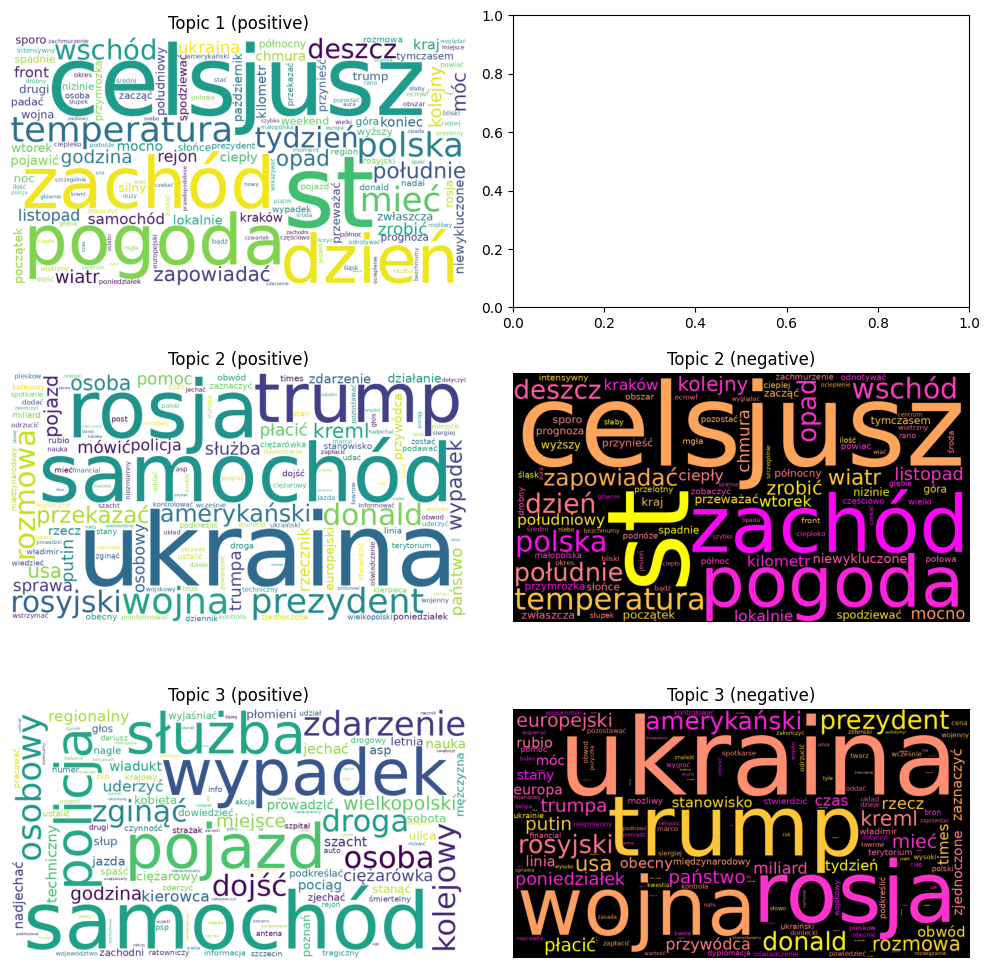

Range of coordinates: -0.19861805054951 0.36688467226607596


In [ ]:
fig = plt.figure(figsize=(10, 10))
n_topics = 3

for i in range(n_topics):
    ax = fig.add_subplot(n_topics, 2, 2 * i + 1)
    # positive weights
    wordcloud_pos = generate_wordcloud(V, terms, topic_idx=i, sign='pos', topn=150)
    if wordcloud_pos:
        ax.imshow(wordcloud_pos)
        ax.axis('off')
        ax.set_title(f"Topic {i+1} (positive)")

    ax = fig.add_subplot(n_topics, 2, 2 * i + 2)
    # negative weights
    wordcloud_neg = generate_wordcloud(V, terms, topic_idx=i, sign='neg', topn=150)
    if wordcloud_neg:
        ax.imshow(wordcloud_neg)
        ax.axis('off')
        ax.set_title(f"Topic {i+1} (negative)")

plt.tight_layout()
plt.show()

print("Range of coordinates:", V.min(), V.max())

## 7. Document-topic visualization

Using radar charts to compare document-topic associations.

In [ ]:
def radar_chart(US, doc_names, doc_selection):
    categories = [f'Topic {i+1}' for i in range(US.shape[1])]
    categories_closed = categories + [categories[0]]

    fig = go.Figure()

    U_abs = np.abs(US)
    r_range = [0, U_abs.max() * 1.1]

    for idx in doc_selection:
        doc_name = doc_names[idx]

        values = U_abs[idx, :].tolist()
        values_closed = values + [values[0]]

        fig.add_trace(go.Scatterpolar(
            r=values_closed,
            theta=categories_closed,
            fill='toself',
            name=doc_name
        ))

    fig.update_layout(
        title='Document-topic associations on a radar chart',
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=r_range
            )
        ),
        showlegend=True
    )

    fig.show()

In [ ]:
docs_selection = range(9)
print([fileids[index] for index in docs_selection])
radar_chart(US, fileids, docs_selection)

['Politics 1', 'Politics 2', 'Politics 3', 'Accident 1', 'Accident 2', 'Accident 3', 'Weather 1', 'Weather 2', 'Weather 3']


In [ ]:
docs_selection = range(2, 5)
print([fileids[index] for index in docs_selection])
radar_chart(US, fileids, docs_selection)

['Politics 3', 'Accident 1', 'Accident 2']


In [ ]:
docs_selection = range(4, 9)
print([fileids[index] for index in docs_selection])
radar_chart(US, fileids, docs_selection)

['Accident 2', 'Accident 3', 'Weather 1', 'Weather 2', 'Weather 3']


## Conclusion

SVD-based LSI reveals latent semantic patterns in the corpus.  
The extracted topics differentiate document domains, while visualizations support interpretation of both terms and documents.